In [310]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [311]:
pd.set_option('display.max_columns', None)

In [312]:
df = pd.read_csv('gurgaon_properties_outlier_treaded.csv')

In [313]:
print(df.columns.tolist())

['property_type', 'society', 'sector', 'price', 'price_per_sqft', 'area', 'areaWithType', 'bedRoom', 'bathroom', 'balcony', 'floorNum', 'facing', 'agePossession', 'super_built_up_area', 'built_up_area', 'carpet_area', 'study room', 'servant room', 'store room', 'pooja room', 'others', 'furnishing_type', 'luxury_score', 'area_room_ratio']


In [314]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,area_room_ratio
0,flat,sbtl caladium,sector 109,1.30,6915.0,1880.0,Super Built up area 1880(174.66 sq.m.),3.0,2.0,3,16.0,East,Moderately Old,1880.0,NaN,NaN,0.0,0.0,0.0,0.0,0.0,1.0,134.0,626.666667
1,flat,bestech park view sanskruti,sector 92,1.83,7871.0,2325.0,Super Built up area 2325(216 sq.m.),4.0,3.0,3,8.0,East,New Property,2325.0,NaN,NaN,0.0,1.0,0.0,0.0,0.0,1.0,128.0,581.250000
2,flat,gls arawali homes,sohna road,0.28,5983.0,468.0,Carpet area: 468 (43.48 sq.m.),2.0,2.0,2,3.0,NaN,Relatively New,NaN,NaN,468.0,0.0,0.0,0.0,0.0,0.0,1.0,42.0,234.000000
3,flat,ats triumph,sector 104,2.60,8254.0,3150.0,Super Built up area 3150(292.64 sq.m.),4.0,4.0,3+,12.0,South,Relatively New,3150.0,NaN,NaN,0.0,1.0,0.0,0.0,0.0,1.0,118.0,787.500000
4,house,independent,sector 12,0.70,4118.0,1700.0,Plot area 1700(157.94 sq.m.),4.0,4.0,1,2.0,NaN,Moderately Old,NaN,1700.0,NaN,0.0,0.0,0.0,0.0,0.0,1.0,0.0,425.000000


In [315]:
print(df.columns.tolist())

['property_type', 'society', 'sector', 'price', 'price_per_sqft', 'area', 'areaWithType', 'bedRoom', 'bathroom', 'balcony', 'floorNum', 'facing', 'agePossession', 'super_built_up_area', 'built_up_area', 'carpet_area', 'study room', 'servant room', 'store room', 'pooja room', 'others', 'furnishing_type', 'luxury_score', 'area_room_ratio']


In [316]:
df.isnull().sum()

property_type             0
society                   1
sector                    0
price                     0
price_per_sqft            0
area                      0
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
floorNum                 16
facing                 1009
agePossession             0
super_built_up_area    1683
built_up_area          1971
carpet_area            1707
study room                0
servant room              0
store room                0
pooja room                0
others                    0
furnishing_type           0
luxury_score              0
area_room_ratio           0
dtype: int64

### Built up area

In [317]:
print(df.columns.tolist())

['property_type', 'society', 'sector', 'price', 'price_per_sqft', 'area', 'areaWithType', 'bedRoom', 'bathroom', 'balcony', 'floorNum', 'facing', 'agePossession', 'super_built_up_area', 'built_up_area', 'carpet_area', 'study room', 'servant room', 'store room', 'pooja room', 'others', 'furnishing_type', 'luxury_score', 'area_room_ratio']


<Axes: xlabel='built_up_area', ylabel='super_built_up_area'>

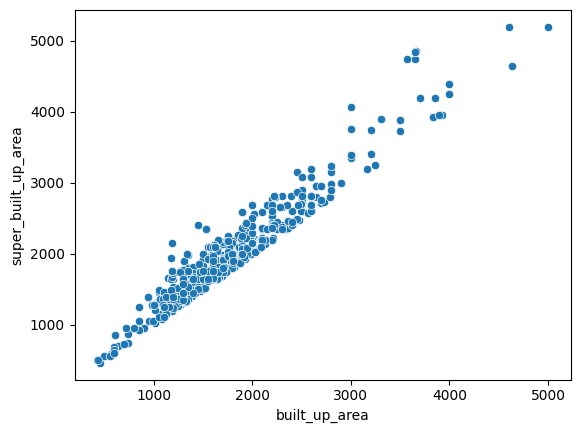

In [318]:
sns.scatterplot(
    x='built_up_area',
    y='super_built_up_area',
    data=df
)

<Axes: xlabel='built_up_area', ylabel='carpet_area'>

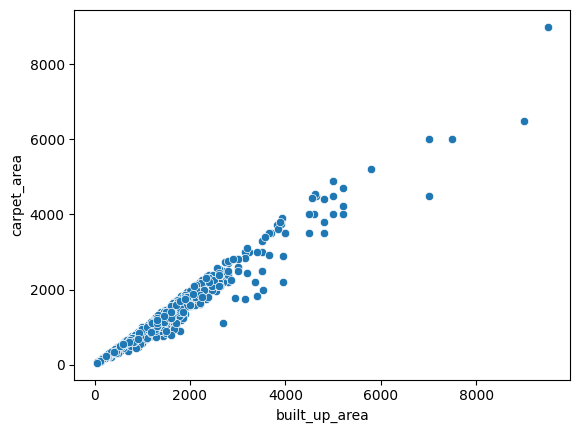

In [319]:
sns.scatterplot(
    x='built_up_area',
    y='carpet_area',
    data=df
)

In [320]:
((df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & (df['carpet_area'].isnull()))

0       False
1       False
2       False
3       False
4       False
        ...  
3548    False
3549    False
3550    False
3551    False
3552    False
Length: 3553, dtype: bool

In [321]:
print(df.columns.tolist())

['property_type', 'society', 'sector', 'price', 'price_per_sqft', 'area', 'areaWithType', 'bedRoom', 'bathroom', 'balcony', 'floorNum', 'facing', 'agePossession', 'super_built_up_area', 'built_up_area', 'carpet_area', 'study room', 'servant room', 'store room', 'pooja room', 'others', 'furnishing_type', 'luxury_score', 'area_room_ratio']


In [322]:
all_present_df = df[~((df['super_built_up_area'].isnull()) | (df['built_up_area'].isnull()) | (df['carpet_area'].isnull()))]

In [323]:
all_present_df.shape

(529, 24)

In [324]:
super_to_built_up_ratio = (all_present_df['super_built_up_area']/all_present_df['built_up_area']).median()

In [325]:
carpet_to_built_up_ratio = (all_present_df['carpet_area']/all_present_df['built_up_area']).median()

In [326]:
print(super_to_built_up_ratio, carpet_to_built_up_ratio)

1.1051948051948053 0.900280112044818


In [327]:
# both present built up null
sbc_df = df[~(df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & ~(df['carpet_area'].isnull())]

In [328]:
sbc_df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,area_room_ratio
14,flat,signature andour heights,sector 71,0.60,10000.0,600.0,Super Built up area 600(55.74 sq.m.)Carpet are...,2.0,2.0,1,5.0,South-West,Relatively New,600.0,NaN,514.0,0.0,0.0,0.0,1.0,0.0,1.0,59.0,300.000000
22,flat,m3m golfestate,sector 65,6.10,18139.0,3363.0,Super Built up area 3363(312.43 sq.m.)Carpet a...,3.0,3.0,3,19.0,North-East,Moderately Old,3363.0,NaN,2710.0,1.0,1.0,0.0,0.0,0.0,0.0,174.0,1121.000000
34,flat,puri diplomatic greens,sector 111,2.65,13590.0,1950.0,Super Built up area 2215(205.78 sq.m.)Carpet a...,3.0,4.0,2,7.0,West,Relatively New,2215.0,NaN,1950.0,0.0,1.0,0.0,0.0,0.0,0.0,159.0,650.000000
82,flat,shapoorji pallonji joyville gurugram,sector 102,1.95,13929.0,1400.0,Super Built up area 1852(172.06 sq.m.)Carpet a...,3.0,3.0,3,6.0,North-East,New Property,1852.0,NaN,1400.0,0.0,0.0,0.0,1.0,0.0,0.0,174.0,466.666667
91,flat,eldeco accolade,sohna road,0.72,4976.0,1447.0,Super Built up area 1457(135.36 sq.m.)Carpet a...,2.0,2.0,3+,12.0,East,Relatively New,1457.0,NaN,849.0,1.0,0.0,0.0,0.0,0.0,1.0,152.0,723.500000


In [329]:
print(df.columns.tolist())

['property_type', 'society', 'sector', 'price', 'price_per_sqft', 'area', 'areaWithType', 'bedRoom', 'bathroom', 'balcony', 'floorNum', 'facing', 'agePossession', 'super_built_up_area', 'built_up_area', 'carpet_area', 'study room', 'servant room', 'store room', 'pooja room', 'others', 'furnishing_type', 'luxury_score', 'area_room_ratio']


In [330]:
sbc_df['built_up_area'] = sbc_df['built_up_area'].fillna(
    (
        (
            (sbc_df['super_built_up_area'] / 1.105) +
            (sbc_df['carpet_area'] / 0.9)
        ) / 2
    ).round()
)

In [331]:
print(df.columns.tolist())

['property_type', 'society', 'sector', 'price', 'price_per_sqft', 'area', 'areaWithType', 'bedRoom', 'bathroom', 'balcony', 'floorNum', 'facing', 'agePossession', 'super_built_up_area', 'built_up_area', 'carpet_area', 'study room', 'servant room', 'store room', 'pooja room', 'others', 'furnishing_type', 'luxury_score', 'area_room_ratio']


In [332]:
df.update(sbc_df)

In [333]:
print(df.columns.tolist())

['property_type', 'society', 'sector', 'price', 'price_per_sqft', 'area', 'areaWithType', 'bedRoom', 'bathroom', 'balcony', 'floorNum', 'facing', 'agePossession', 'super_built_up_area', 'built_up_area', 'carpet_area', 'study room', 'servant room', 'store room', 'pooja room', 'others', 'furnishing_type', 'luxury_score', 'area_room_ratio']


In [334]:
df.isnull().sum()

property_type             0
society                   1
sector                    0
price                     0
price_per_sqft            0
area                      0
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
floorNum                 16
facing                 1009
agePossession             0
super_built_up_area    1683
built_up_area          1549
carpet_area            1707
study room                0
servant room              0
store room                0
pooja room                0
others                    0
furnishing_type           0
luxury_score              0
area_room_ratio           0
dtype: int64

In [335]:
print(df.columns.tolist())

['property_type', 'society', 'sector', 'price', 'price_per_sqft', 'area', 'areaWithType', 'bedRoom', 'bathroom', 'balcony', 'floorNum', 'facing', 'agePossession', 'super_built_up_area', 'built_up_area', 'carpet_area', 'study room', 'servant room', 'store room', 'pooja room', 'others', 'furnishing_type', 'luxury_score', 'area_room_ratio']


In [336]:
# sb present c is null built up null
sb_df = df[~(df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & (df['carpet_area'].isnull())]

In [337]:
print(df.columns.tolist())

['property_type', 'society', 'sector', 'price', 'price_per_sqft', 'area', 'areaWithType', 'bedRoom', 'bathroom', 'balcony', 'floorNum', 'facing', 'agePossession', 'super_built_up_area', 'built_up_area', 'carpet_area', 'study room', 'servant room', 'store room', 'pooja room', 'others', 'furnishing_type', 'luxury_score', 'area_room_ratio']


In [338]:
sb_df.head()


,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,area_room_ratio
0,flat,sbtl caladium,sector 109,1.30,6915.0,1880.0,Super Built up area 1880(174.66 sq.m.),3.0,2.0,3,16.0,East,Moderately Old,1880.0,NaN,NaN,0.0,0.0,0.0,0.0,0.0,1.0,134.0,626.666667
1,flat,bestech park view sanskruti,sector 92,1.83,7871.0,2325.0,Super Built up area 2325(216 sq.m.),4.0,3.0,3,8.0,East,New Property,2325.0,NaN,NaN,0.0,1.0,0.0,0.0,0.0,1.0,128.0,581.250000
3,flat,ats triumph,sector 104,2.60,8254.0,3150.0,Super Built up area 3150(292.64 sq.m.),4.0,4.0,3+,12.0,South,Relatively New,3150.0,NaN,NaN,0.0,1.0,0.0,0.0,0.0,1.0,118.0,787.500000
5,flat,microtek greenburg,sector 86,1.23,8311.0,1480.0,Super Built up area 1480(137.5 sq.m.),2.0,2.0,3,13.0,South,Relatively New,1480.0,NaN,NaN,1.0,0.0,0.0,0.0,0.0,1.0,6.0,740.000000
8,flat,shree vardhman flora,sector 90,0.90,4615.0,1950.0,Super Built up area 1950(181.16 sq.m.),3.0,4.0,3,4.0,East,Relatively New,1950.0,NaN,NaN,0.0,1.0,0.0,0.0,0.0,1.0,165.0,650.000000


In [339]:
print(df.columns.tolist())

['property_type', 'society', 'sector', 'price', 'price_per_sqft', 'area', 'areaWithType', 'bedRoom', 'bathroom', 'balcony', 'floorNum', 'facing', 'agePossession', 'super_built_up_area', 'built_up_area', 'carpet_area', 'study room', 'servant room', 'store room', 'pooja room', 'others', 'furnishing_type', 'luxury_score', 'area_room_ratio']


In [340]:
sb_df['built_up_area'] = sb_df['built_up_area'].fillna(
    round(sb_df['super_built_up_area'] / 1.105)
    
)

In [341]:
print(df.columns.tolist())

['property_type', 'society', 'sector', 'price', 'price_per_sqft', 'area', 'areaWithType', 'bedRoom', 'bathroom', 'balcony', 'floorNum', 'facing', 'agePossession', 'super_built_up_area', 'built_up_area', 'carpet_area', 'study room', 'servant room', 'store room', 'pooja room', 'others', 'furnishing_type', 'luxury_score', 'area_room_ratio']


In [342]:
df.update(sb_df)

In [343]:
df.isnull().sum()

property_type             0
society                   1
sector                    0
price                     0
price_per_sqft            0
area                      0
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
floorNum                 16
facing                 1009
agePossession             0
super_built_up_area    1683
built_up_area           678
carpet_area            1707
study room                0
servant room              0
store room                0
pooja room                0
others                    0
furnishing_type           0
luxury_score              0
area_room_ratio           0
dtype: int64

In [344]:
df.columns.tolist()

['property_type',
 'society',
 'sector',
 'price',
 'price_per_sqft',
 'area',
 'areaWithType',
 'bedRoom',
 'bathroom',
 'balcony',
 'floorNum',
 'facing',
 'agePossession',
 'super_built_up_area',
 'built_up_area',
 'carpet_area',
 'study room',
 'servant room',
 'store room',
 'pooja room',
 'others',
 'furnishing_type',
 'luxury_score',
 'area_room_ratio']

In [345]:
c_df = df[
    df['super_built_up_area'].isna() &
    df['built_up_area'].isna() &
    df['carpet_area'].notna()
]

In [346]:
c_df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,area_room_ratio
2,flat,gls arawali homes,sohna road,0.28,5983.0,468.0,Carpet area: 468 (43.48 sq.m.),2.0,2.0,2,3.0,NaN,Relatively New,NaN,NaN,468.0,0.0,0.0,0.0,0.0,0.0,1.0,42.0,234.00
6,flat,raheja the vedaanta floors,sector 108,0.70,4522.0,1548.0,Carpet area: 1548 (143.81 sq.m.),2.0,2.0,3,1.0,NaN,Moderately Old,NaN,NaN,1548.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,774.00
29,flat,laxmi pareena,sector 99a,0.30,6667.0,450.0,Carpet area: 450 (41.81 sq.m.),2.0,1.0,0,12.0,North,Undefined,NaN,NaN,450.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,225.00
39,flat,tulip white,sector 69,0.90,6787.0,1326.0,Carpet area: 1326 (123.19 sq.m.),3.0,2.0,3,6.0,North-East,Relatively New,NaN,NaN,1326.0,0.0,0.0,0.0,1.0,0.0,1.0,121.0,442.00
41,flat,smartworld 1dxp,sector 113,2.75,10589.0,2597.0,Carpet area: 2597 (241.27 sq.m.),4.0,4.0,3+,20.0,East,Under Construction,NaN,NaN,2597.0,1.0,1.0,0.0,1.0,0.0,2.0,57.0,649.25


In [347]:
print(df.columns.tolist())

['property_type', 'society', 'sector', 'price', 'price_per_sqft', 'area', 'areaWithType', 'bedRoom', 'bathroom', 'balcony', 'floorNum', 'facing', 'agePossession', 'super_built_up_area', 'built_up_area', 'carpet_area', 'study room', 'servant room', 'store room', 'pooja room', 'others', 'furnishing_type', 'luxury_score', 'area_room_ratio']


In [348]:
c_df['built_up_area'] = c_df['built_up_area'].fillna(
    round(c_df['carpet_area'] / 0.9)
)

In [349]:
print(df.columns.tolist())

['property_type', 'society', 'sector', 'price', 'price_per_sqft', 'area', 'areaWithType', 'bedRoom', 'bathroom', 'balcony', 'floorNum', 'facing', 'agePossession', 'super_built_up_area', 'built_up_area', 'carpet_area', 'study room', 'servant room', 'store room', 'pooja room', 'others', 'furnishing_type', 'luxury_score', 'area_room_ratio']


In [350]:
df.update(c_df)

In [351]:
df.isnull().sum()

property_type             0
society                   1
sector                    0
price                     0
price_per_sqft            0
area                      0
areaWithType              0
bedRoom                   0
bathroom                  0
balcony                   0
floorNum                 16
facing                 1009
agePossession             0
super_built_up_area    1683
built_up_area             0
carpet_area            1707
study room                0
servant room              0
store room                0
pooja room                0
others                    0
furnishing_type           0
luxury_score              0
area_room_ratio           0
dtype: int64

<Axes: xlabel='built_up_area', ylabel='price'>

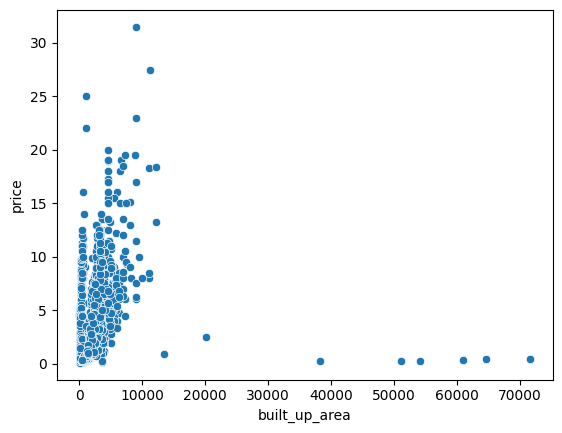

In [352]:
sns.scatterplot(
    x='built_up_area',
    y='price',
    data=df
)

In [353]:
print(df.columns.tolist())

['property_type', 'society', 'sector', 'price', 'price_per_sqft', 'area', 'areaWithType', 'bedRoom', 'bathroom', 'balcony', 'floorNum', 'facing', 'agePossession', 'super_built_up_area', 'built_up_area', 'carpet_area', 'study room', 'servant room', 'store room', 'pooja room', 'others', 'furnishing_type', 'luxury_score', 'area_room_ratio']


In [354]:
anamoly_df = df[(df['built_up_area'] < 2000) & (df['price'] > 2.5)][['price','area','built_up_area']]

In [355]:
print(df.columns.tolist())

['property_type', 'society', 'sector', 'price', 'price_per_sqft', 'area', 'areaWithType', 'bedRoom', 'bathroom', 'balcony', 'floorNum', 'facing', 'agePossession', 'super_built_up_area', 'built_up_area', 'carpet_area', 'study room', 'servant room', 'store room', 'pooja room', 'others', 'furnishing_type', 'luxury_score', 'area_room_ratio']


In [356]:
anamoly_df.sample(5)

,price,area,built_up_area
1966,14.00,6300.0,700.0
3068,10.00,4950.0,550.0
601,4.75,2367.0,261.0
414,6.60,1800.0,1800.0
2870,3.95,2343.0,1900.0


In [357]:
anamoly_df['built_up_area'] = anamoly_df['area']

In [358]:
print(df.columns.tolist())

['property_type', 'society', 'sector', 'price', 'price_per_sqft', 'area', 'areaWithType', 'bedRoom', 'bathroom', 'balcony', 'floorNum', 'facing', 'agePossession', 'super_built_up_area', 'built_up_area', 'carpet_area', 'study room', 'servant room', 'store room', 'pooja room', 'others', 'furnishing_type', 'luxury_score', 'area_room_ratio']


In [359]:
df.update(anamoly_df)

In [360]:
print(df.columns.tolist())

['property_type', 'society', 'sector', 'price', 'price_per_sqft', 'area', 'areaWithType', 'bedRoom', 'bathroom', 'balcony', 'floorNum', 'facing', 'agePossession', 'super_built_up_area', 'built_up_area', 'carpet_area', 'study room', 'servant room', 'store room', 'pooja room', 'others', 'furnishing_type', 'luxury_score', 'area_room_ratio']


<Axes: xlabel='built_up_area', ylabel='price'>

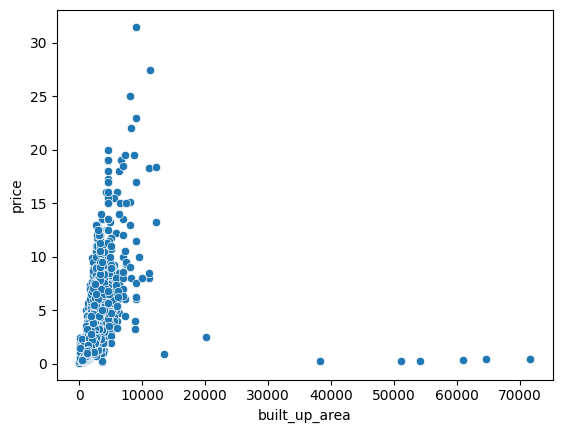

In [361]:
sns.scatterplot(
    x='built_up_area',
    y='price',
    data=df
)

In [362]:
print(df.columns.tolist())

['property_type', 'society', 'sector', 'price', 'price_per_sqft', 'area', 'areaWithType', 'bedRoom', 'bathroom', 'balcony', 'floorNum', 'facing', 'agePossession', 'super_built_up_area', 'built_up_area', 'carpet_area', 'study room', 'servant room', 'store room', 'pooja room', 'others', 'furnishing_type', 'luxury_score', 'area_room_ratio']


In [363]:
df.drop(columns=['area','areaWithType','super_built_up_area','carpet_area','area_room_ratio'],inplace=True)

In [364]:
df.head()

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,facing,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,sbtl caladium,sector 109,1.30,6915.0,3.0,2.0,3,16.0,East,Moderately Old,1701.0,0.0,0.0,0.0,0.0,0.0,1.0,134.0
1,flat,bestech park view sanskruti,sector 92,1.83,7871.0,4.0,3.0,3,8.0,East,New Property,2104.0,0.0,1.0,0.0,0.0,0.0,1.0,128.0
2,flat,gls arawali homes,sohna road,0.28,5983.0,2.0,2.0,2,3.0,NaN,Relatively New,520.0,0.0,0.0,0.0,0.0,0.0,1.0,42.0
3,flat,ats triumph,sector 104,2.60,8254.0,4.0,4.0,3+,12.0,South,Relatively New,2851.0,0.0,1.0,0.0,0.0,0.0,1.0,118.0
4,house,independent,sector 12,0.70,4118.0,4.0,4.0,1,2.0,NaN,Moderately Old,1700.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [365]:
df.isnull().sum()

property_type         0
society               1
sector                0
price                 0
price_per_sqft        0
bedRoom               0
bathroom              0
balcony               0
floorNum             16
facing             1009
agePossession         0
built_up_area         0
study room            0
servant room          0
store room            0
pooja room            0
others                0
furnishing_type       0
luxury_score          0
dtype: int64

### floorNum

In [366]:
df[df['floorNum'].isnull()]

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,facing,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
100,house,dlf new town heights,sector 86,2.47,7719.0,4.0,4.0,3+,NaN,West,Moderately Old,2800.0,0.0,1.0,0.0,1.0,0.0,0.0,130.0
124,house,independent,sector 3,1.50,10288.0,3.0,3.0,0,NaN,NaN,Old Property,210.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
240,house,ansal sushant lok,sector 43,10.50,27911.0,4.0,4.0,2,NaN,North-East,Old Property,3762.0,0.0,1.0,0.0,0.0,0.0,1.0,59.0
277,house,independent,sector 25,13.00,45710.0,6.0,8.0,3+,NaN,NaN,Relatively New,2844.0,1.0,1.0,1.0,1.0,0.0,2.0,0.0
411,house,ansal sushant lok plots,sector 43,3.30,26570.0,1.0,1.0,0,NaN,NaN,Under Construction,1242.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1915,house,independent,sector 2,5.60,17284.0,8.0,6.0,3+,NaN,South-West,Moderately Old,3240.0,1.0,1.0,1.0,1.0,0.0,1.0,0.0
1921,house,emaar mgf marbella,sector 66,9.00,21251.0,4.0,4.0,3+,NaN,South-West,Relatively New,5200.0,0.0,1.0,1.0,1.0,0.0,0.0,114.0
2032,house,independent,sector 26,4.60,12198.0,4.0,4.0,3+,NaN,NaN,Old Property,3771.0,0.0,0.0,0.0,0.0,0.0,1.0,28.0
2223,house,independent,sector 24,1.45,2984.0,3.0,3.0,1,NaN,NaN,Old Property,540.0,0.0,0.0,0.0,0.0,0.0,1.0,9.0
2325,flat,NaN,sector 78,0.60,3692.0,2.0,2.0,0,NaN,NaN,Under Construction,1625.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [367]:
df[df['property_type'] == 'house']['floorNum'].median()

np.float64(2.0)

In [369]:
df['floorNum'] = df['floorNum'].fillna(2.0)

In [370]:
df.isnull().sum()

property_type         0
society               1
sector                0
price                 0
price_per_sqft        0
bedRoom               0
bathroom              0
balcony               0
floorNum              0
facing             1009
agePossession         0
built_up_area         0
study room            0
servant room          0
store room            0
pooja room            0
others                0
furnishing_type       0
luxury_score          0
dtype: int64

In [371]:
1011/df.shape[0]

0.2845482690683929

### facing

<Axes: >

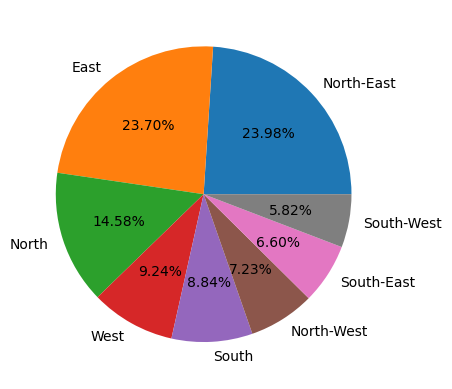

In [372]:
df['facing'].value_counts().plot(kind='pie',autopct='%0.2f%%')

In [373]:
df.drop(columns=['facing'],inplace=True)

In [374]:
df.sample(5)

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
60,flat,the lions cghs,sector 56,2.05,7885.0,4.0,4.0,3+,7.0,Old Property,2600.0,0.0,0.0,1.0,0.0,0.0,0.0,120.0
1457,house,satya the legend,sector 57,9.25,16577.0,5.0,5.0,3+,4.0,Relatively New,5580.0,1.0,1.0,1.0,1.0,0.0,0.0,160.0
3052,flat,smart world orchard,sector 61,1.55,13478.0,2.0,2.0,1,3.0,Under Construction,1041.0,1.0,0.0,0.0,0.0,0.0,1.0,43.0
2554,flat,bestech park view ananda,sector 81,1.10,6687.0,3.0,2.0,3+,5.0,Relatively New,1319.0,0.0,0.0,0.0,0.0,0.0,1.0,150.0
667,flat,bestech park view city,sector 48,2.70,11714.0,3.0,3.0,3+,7.0,Relatively New,2000.0,1.0,1.0,0.0,0.0,0.0,0.0,174.0


In [375]:
df.isnull().sum()

property_type      0
society            1
sector             0
price              0
price_per_sqft     0
bedRoom            0
bathroom           0
balcony            0
floorNum           0
agePossession      0
built_up_area      0
study room         0
servant room       0
store room         0
pooja room         0
others             0
furnishing_type    0
luxury_score       0
dtype: int64

In [376]:
df.drop(index=[2536],inplace=True)

In [377]:
df.isnull().sum()

property_type      0
society            1
sector             0
price              0
price_per_sqft     0
bedRoom            0
bathroom           0
balcony            0
floorNum           0
agePossession      0
built_up_area      0
study room         0
servant room       0
store room         0
pooja room         0
others             0
furnishing_type    0
luxury_score       0
dtype: int64

### agePossession

In [378]:
df['agePossession'].value_counts()

agePossession
Relatively New        1609
New Property           556
Moderately Old         540
Old Property           293
Undefined              290
Under Construction     264
Name: count, dtype: int64

In [379]:
df[df['agePossession'] == 'Undefined']

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
7,flat,sare crescent parc,sector 92,0.95,5013.0,4.0,5.0,3+,13.0,Undefined,1895.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
18,flat,imperia elvedor,sector 37c,0.55,8221.0,1.0,1.0,0,5.0,Undefined,669.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
29,flat,laxmi pareena,sector 99a,0.30,6667.0,2.0,1.0,0,12.0,Undefined,500.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
33,flat,supertech hilltown,sector 2,0.80,5556.0,3.0,2.0,3,8.0,Undefined,1440.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
52,house,independent,sector 3,0.90,8929.0,3.0,3.0,0,2.0,Undefined,112.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3510,flat,sidhartha ncr one phase,sector 95,0.46,4646.0,2.0,2.0,0,6.0,Undefined,990.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3538,house,independent,sector 105,0.70,5833.0,3.0,2.0,2,1.0,Undefined,1200.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3541,flat,m3m skycity,sector 65,2.80,15317.0,3.0,3.0,0,14.0,Undefined,1828.0,0.0,0.0,0.0,0.0,0.0,1.0,39.0
3545,house,independent,sector 2,5.00,15385.0,6.0,6.0,2,1.0,Undefined,3611.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [380]:
def mode_based_imputation(row):
    if row['agePossession'] == 'Undefined':
        mode_value = df[(df['sector'] == row['sector']) & (df['property_type'] == row['property_type'])]['agePossession'].mode()
        # If mode_value is empty (no mode found), return NaN, otherwise return the mode
        if not mode_value.empty:
            return mode_value.iloc[0] 
        else:
            return np.nan
    else:
        return row['agePossession']

In [381]:
df['agePossession'] = df.apply(mode_based_imputation,axis=1)

In [382]:
df['agePossession'].value_counts()

agePossession
Relatively New        1733
New Property           585
Moderately Old         578
Old Property           325
Under Construction     278
Undefined               53
Name: count, dtype: int64

In [383]:
def mode_based_imputation2(row):
    if row['agePossession'] == 'Undefined':
        mode_value = df[(df['sector'] == row['sector'])]['agePossession'].mode()
        # If mode_value is empty (no mode found), return NaN, otherwise return the mode
        if not mode_value.empty:
            return mode_value.iloc[0] 
        else:
            return np.nan
    else:
        return row['agePossession']

In [384]:
df['agePossession'] = df.apply(mode_based_imputation2,axis=1)

In [385]:
df['agePossession'].value_counts()

agePossession
Relatively New        1744
New Property           586
Moderately Old         584
Old Property           335
Under Construction     278
Undefined               25
Name: count, dtype: int64

In [386]:
def mode_based_imputation3(row):
    if row['agePossession'] == 'Undefined':
        mode_value = df[(df['property_type'] == row['property_type'])]['agePossession'].mode()
        # If mode_value is empty (no mode found), return NaN, otherwise return the mode
        if not mode_value.empty:
            return mode_value.iloc[0] 
        else:
            return np.nan
    else:
        return row['agePossession']

In [387]:
df['agePossession'] = df.apply(mode_based_imputation3,axis=1)

In [388]:
df['agePossession'].value_counts()

agePossession
Relatively New        1746
Moderately Old         607
New Property           586
Old Property           335
Under Construction     278
Name: count, dtype: int64

In [389]:
df.isnull().sum()

property_type      0
society            1
sector             0
price              0
price_per_sqft     0
bedRoom            0
bathroom           0
balcony            0
floorNum           0
agePossession      0
built_up_area      0
study room         0
servant room       0
store room         0
pooja room         0
others             0
furnishing_type    0
luxury_score       0
dtype: int64

In [393]:
df.to_csv('gurgaon_properties_missing_value_imputation_final.csv',index=False)

In [391]:
df.shape

(3552, 18)